In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy
import pandas as pd
from numpy.random import choice

In [2]:
import emcee
import pymc

In [3]:
from scipy import integrate
from scipy.stats import norm
from scipy.stats import cauchy


In [4]:
path = '../solutions/transient.npy'

In [5]:
data = np.load(path)
np.shape(data)
times = []
F = []
sF = []
for i in range(100):
    times = np.append(times,data[i][0])
    F = np.append(F,data[i][1])
    sF = np.append(sF,data[i][2])



<ErrorbarContainer object of 3 artists>

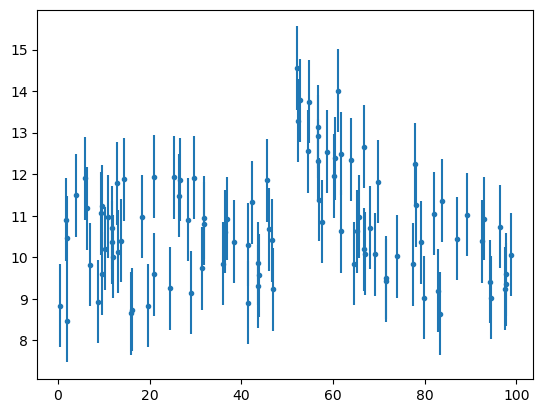

In [6]:
plt.errorbar(times,F,sF,linestyle='',fmt='.')

In [ ]:
#data[1] flux, data[2] err on flux

In [7]:
theta0 = np.array([5,10,50,0.1])

In [8]:
Amin, Amax = 0, 50
bmin, bmax = 0, 50
t0min, t0max = 0, 100
alphamin, alphamax = np.exp(-5),np.exp(5)

In [39]:
def b_model(theta,t):
    A,b,t0,alpha=theta 
    return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))

In [40]:
def log_likelihood(theta, x, y, yerr):
    A,b,t0,alpha = theta
    y_model = b_model(theta,x)

    return -0.5 * np.sum((y - y_model) ** 2 / yerr**2 )
        
def log_prior(theta):
    A,b,t0,alpha=theta 
    if Amin < A < Amax and bmin < b < bmax and t0min < t0 < t0max and alphamin < alpha < alphamax:
        return - np.log(alpha)
    return -np.inf
                   
def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

In [41]:
ndim = 4  # number of parameters in the model
nwalkers = 20  # number of MCMC walkers
nsteps = int(1e4)  # number of MCMC steps to take **for each walker**
pos = theta0 + 1e-1 * np.random.randn(nwalkers, ndim)

In [42]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(times, F, sF)
)

In [43]:
sampler.run_mcmc(pos, nsteps, progress=True)

100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:05<00:00, 1853.40it/s]


State([[ 6.77356786 10.38836293 48.41966519  0.14498291]
 [ 4.32281091 10.16448246 50.48440949  0.1126121 ]
 [ 5.48757782  9.91674467 51.55757109  0.14103978]
 [ 4.12611576 10.25464794 51.70429264  0.09545561]
 [ 6.23205908 10.37499911 47.24331429  0.09824589]
 [ 7.25551629 10.2155661  47.68195563  0.12620052]
 [ 4.54567617 10.37067447 49.77899487  0.1118757 ]
 [ 9.39916414 10.35538952 47.01686459  0.16751855]
 [ 6.6188684  10.37291915 48.78715376  0.1386964 ]
 [ 4.91033402 10.51082739 48.44605163  0.10794276]
 [ 8.52720135 10.14749044 48.34628204  0.13264213]
 [ 4.00780221 10.28402321 50.94685713  0.10092904]
 [ 3.82582238 10.16739054 51.81638795  0.07953427]
 [ 8.07885699 10.25645661 48.46179565  0.17739942]
 [ 7.42686181 10.30959148 48.94127803  0.14657393]
 [ 4.80095363 10.29710367 48.88428541  0.09702907]
 [ 4.0110684  10.2050012  51.55556306  0.10259614]
 [ 5.22828443 10.45196931 51.64109048  0.19815801]
 [11.24270149 10.5886575  46.92657384  0.21299474]
 [ 6.99153354 10.15411529

Text(0.5, 0, 'step number')

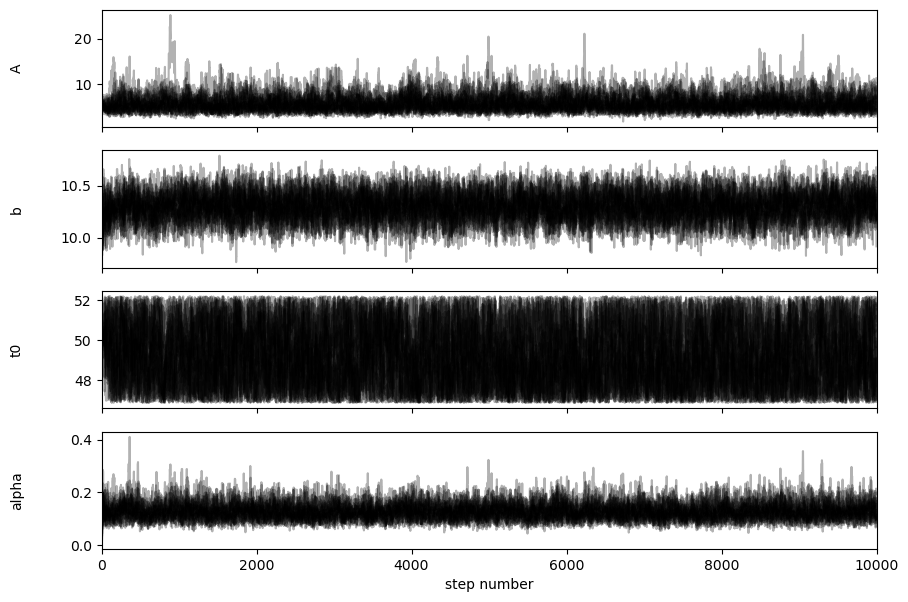

In [44]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["A","b","t0","alpha"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

In [45]:
tau = sampler.get_autocorr_time()
print(tau)

[85.42217239 56.98629742 89.49924227 54.90066014]


In [46]:
#sol del prof

In [47]:
def burst(theta,t):
    A,b,t0,alpha=theta 
    return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))

In [ ]:
t0_quick=50
A_quick=5
b_quick=10
alpha_quick=0.1


theta_quick= np.array([A_quick,b_quick,t0_quick,alpha_quick])

In [ ]:
t0min,t0max = 0,100
Amin,Amax=0,50
bmin,bmax=0,50
alphamin,alphamax=np.exp(-5),np.exp(5)

In [ ]:
def LogLikelihood(theta, data, model=burst):
    x, y, sigma_y = data.T
    y_fit = model(theta, x)
    return -0.5 * np.sum((y-y_fit)**2 / sigma_y**2 ) 

## prior is proportional to 1/alpha
def Logprior(theta):
    A,b,t0,alpha=theta 
    if Amin < A < Amax and bmin < b < bmax and t0min < t0 < t0max and alphamin < alpha < alphamax:
        return 0.0 + 0.0 + 0.0 - np.log(alpha)
    return -np.inf
                   
def LogPosterior(theta,data, model=burst):
    return LogLikelihood(theta,data, model) + Logprior(theta)

In [ ]:
ndim = 4  # number of parameters in the model
nwalkers = 20  # number of MCMC walkers
nsteps = int(1e4)  # number of MCMC steps to take **for each walker**

starting_guesses = theta_quick + 1e-1* np.random.randn(nwalkers, ndim)

print(starting_guesses.shape)

In [ ]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior, args=[data, burst])
sampler.run_mcmc(starting_guesses, nsteps);

In [ ]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["A","b","t0","alpha"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [ ]:
tau = sampler.get_autocorr_time()
print(tau)

In [ ]:
flat_samples = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True) #chain thinned based on the largest correletion length
print(flat_samples.shape)

In [ ]:

import corner
fig = corner.corner(flat_samples, labels=labels, levels=[0.68,0.95])

In [ ]:
chosen_samples= flat_samples[np.random.choice(len(flat_samples),size=100)]

In [ ]:
tgrid=np.linspace(0,100,100)

for chosen_theta in chosen_samples:
    ygrid =  burst(chosen_theta,tgrid)
    plt.plot(tgrid,ygrid,alpha=0.3,c='gray')
    
plt.errorbar(times,F,yerr=sF,fmt='.')
plt.xlabel("time")
plt.ylabel("flux")